# 08 · Reserving

Unpaid claims for CAS workers' comp and commercial auto from paid triangles, in USD thousands. The triangle is an industry total over companies with complete filings, valued at 2007 (accident years 1998–2007, development through lag 10 is what's observed). Future cells are masked before anything is fitted. Different object from the company-year loss ratios in 05–06.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import reserving_model as rsv

USD000 = lambda v: f"USD {v:,.1f}k"

def money_display(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = out[c].map(lambda v: f'{v:,.1f}')
    return out

VALUATION_YEAR = 2007   # the database's own end -- reproduces the standard Schedule P triangle shape
PRIMARY_LINE = 'wkcomp'
SECONDARY_LINE = 'comauto'

## Triangle construction

Check company/year/lag keys are unique and grids are complete before summing. Only companies with a complete filing grid are kept, so the triangle is a selected sample and not the whole industry. The table below shows how much is retained. The filter uses hindsight, so survivorship bias is possible and its direction is not tested.

In [2]:
tri_wkcomp, report_wkcomp = rsv.build_industry_triangle(DATA_DIR, PRIMARY_LINE)
tri_comauto, report_comauto = rsv.build_industry_triangle(DATA_DIR, SECONDARY_LINE)

print(f"{PRIMARY_LINE}:   {report_wkcomp.n_companies_full_square} of {report_wkcomp.n_companies_total} "
      f"companies are full-square ({report_wkcomp.n_companies_excluded} excluded for incomplete filings)")
print(f"{SECONDARY_LINE}: {report_comauto.n_companies_full_square} of {report_comauto.n_companies_total} "
      f"companies are full-square ({report_comauto.n_companies_excluded} excluded for incomplete filings)")

wkcomp:   110 of 132 companies are full-square (22 excluded for incomplete filings)
comauto: 137 of 157 companies are full-square (20 excluded for incomplete filings)


In [3]:
selection = pd.DataFrame([rsv.selection_summary(DATA_DIR, l) for l in (PRIMARY_LINE, SECONDARY_LINE)]).set_index('line')
selection.round(1)

,companies_total,companies_retained,companies_retained_pct,earned_premium_retained_pct
line,,,,
wkcomp,132,110,83.300,79.200
comauto,157,137,87.300,88.300


Retention is 83% of wkcomp companies (79% of earned premium) and 87% of comauto companies (88% of earned premium). The excluded companies are not in the reserve estimates, so they say nothing about companies with incomplete filings. Unpaid amounts here describe the retained group only.

In [4]:
cum_paid_full = tri_wkcomp['cum_paid']
earned_prem = tri_wkcomp['earned_prem']

cum_paid = rsv.mask_to_valuation(cum_paid_full, VALUATION_YEAR)
print(f"{PRIMARY_LINE} paid-loss triangle, masked to what was known as of calendar year {VALUATION_YEAR} "
      f"(USD '000s, industry-aggregate over {report_wkcomp.n_companies_full_square} full-square companies):")
cum_paid.map(lambda v: '' if pd.isna(v) else f'{v:,.1f}')

wkcomp paid-loss triangle, masked to what was known as of calendar year 2007 (USD '000s, industry-aggregate over 110 full-square companies):


DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,"246,949.0","511,681.0","649,792.0","737,598.0","789,683.0","819,686.0","841,699.0","856,623.0","869,442.0","880,797.0"
1999,"268,158.0","568,947.0","730,259.0","826,453.0","881,983.0","921,350.0","935,069.0","959,007.0","977,490.0",
2000,"323,587.0","693,595.0","874,614.0","979,618.0","1,039,384.0","1,063,719.0","1,102,173.0","1,131,581.0",,
2001,"360,914.0","772,231.0","996,090.0","1,131,026.0","1,195,440.0","1,250,464.0","1,291,068.0",,,
2002,"391,734.0","860,641.0","1,117,925.0","1,264,419.0","1,355,383.0","1,412,147.0",,,,
2003,"428,087.0","910,992.0","1,162,996.0","1,319,603.0","1,411,196.0",,,,,
2004,"463,288.0","969,750.0","1,223,681.0","1,387,891.0",,,,,,
2005,"480,904.0","986,915.0","1,257,242.0",,,,,,,
2006,"487,301.0","1,019,758.0",,,,,,,,


## Triangle checks

Round-trip between cumulative and incremental, and look for negative increments. Negative net paid development can happen in general; here there are none (0 negative cells, no non-monotonic accident years), for this composite only.

In [5]:
val_report = rsv.validate_triangle(cum_paid)
print(val_report)
assert val_report.cumulative_matches_sum_of_incremental, "cumulative/incremental round-trip failed"
assert val_report.n_negative_incremental == 0, "Selected composite has negative paid increments; review Mack assumptions"
print("Validation passed: no negative incremental paid cells, no non-monotonic accident years, "
      "cumulative/incremental conversion round-trips exactly.")

TriangleValidationReport(n_accident_years=10, n_negative_incremental=0, n_nonmonotonic_ay=0, cumulative_matches_sum_of_incremental=True)
Validation passed: no negative incremental paid cells, no non-monotonic accident years, cumulative/incremental conversion round-trips exactly.


## Development patterns

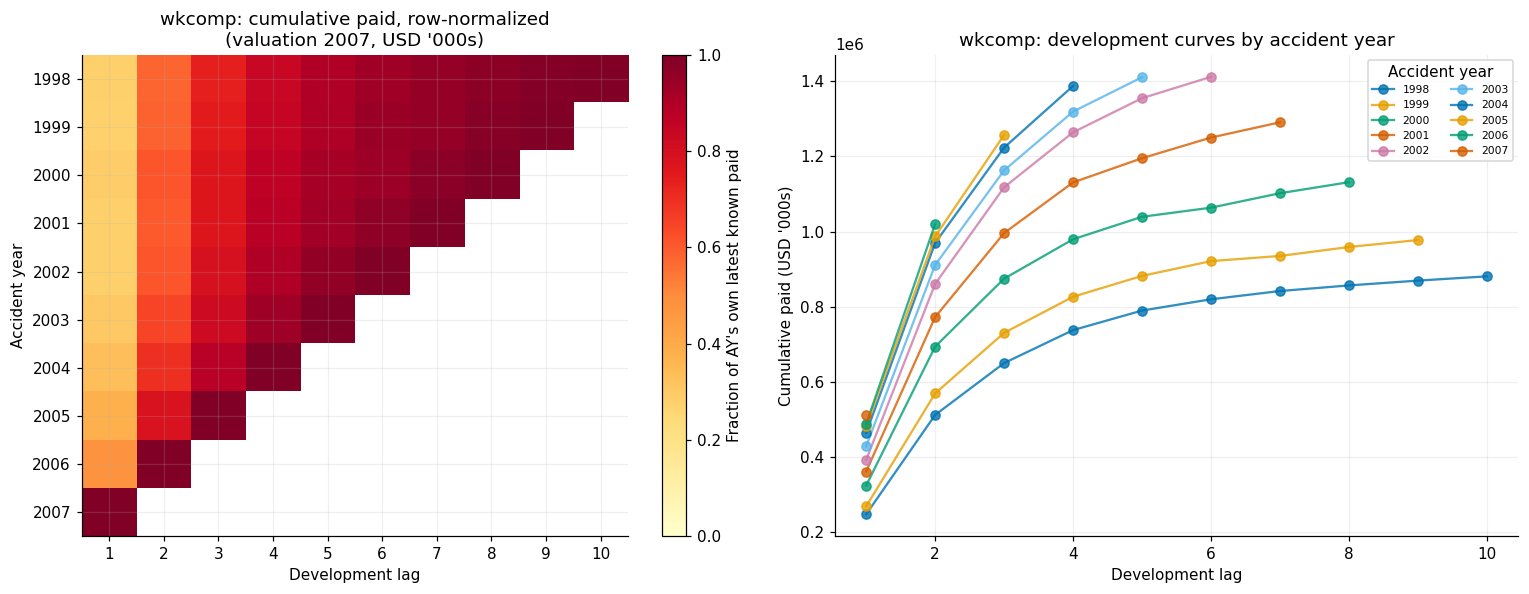

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

norm = cum_paid.div(cum_paid.max(axis=1), axis=0)
im = axes[0].imshow(norm.to_numpy(), aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_xticks(range(len(cum_paid.columns))); axes[0].set_xticklabels(cum_paid.columns)
axes[0].set_yticks(range(len(cum_paid.index))); axes[0].set_yticklabels(cum_paid.index)
axes[0].set_xlabel('Development lag'); axes[0].set_ylabel('Accident year')
axes[0].set_title(f'{PRIMARY_LINE}: cumulative paid, row-normalized\n(valuation {VALUATION_YEAR}, USD \'000s)')
plt.colorbar(im, ax=axes[0], label='Fraction of AY\'s own latest known paid')

for ay in cum_paid.index:
    row = cum_paid.loc[ay].dropna()
    axes[1].plot(row.index, row.to_numpy(), 'o-', label=str(ay), alpha=0.8)
axes[1].set_xlabel('Development lag'); axes[1].set_ylabel("Cumulative paid (USD '000s)")
axes[1].set_title(f'{PRIMARY_LINE}: development curves by accident year')
axes[1].legend(fontsize=7, ncol=2, title='Accident year')

plt.tight_layout(); plt.show()

The curves have similar shapes, but that alone doesn't show the factors are stable.

## Chain-Ladder

Volume-weighted age-to-age factors from the observed pairs, latest paid diagonal times the remaining factors. Factors and ultimates are compared with the chainladder package using the same weighting and tail. wkcomp total unpaid is USD 3,267,680.7k.

In [7]:
cl = rsv.chain_ladder(cum_paid)

print("Volume-weighted age-to-age factors:")
print(cl.age_to_age_factors.round(4))
print()
print("Cumulative development factor to ultimate, by development lag:")
print(cl.cdf_to_ultimate.round(4))

Volume-weighted age-to-age factors:
1   2.114
2   1.277
3   1.132
4   1.066
5   1.039
6   1.028
7   1.024
8   1.017
9   1.013
Name: age_to_age_factor, dtype: float64

Cumulative development factor to ultimate, by development lag:
1    3.672
2    1.737
3    1.360
4    1.202
5    1.127
6    1.085
7    1.055
8    1.030
9    1.013
10   1.000
Name: cdf_to_ultimate, dtype: float64


In [8]:
cl_table = pd.DataFrame({
    'latest_known_paid': cl.latest_diagonal,
    'latest_known_lag': rsv.latest_lag(cum_paid),
    'CL_ultimate': cl.ultimate,
    'CL_unpaid_reserve': cl.unpaid_reserve,
})
cl_table.index.name = 'AccidentYear'
print(f"Total Chain-Ladder unpaid reserve, all accident years: {USD000(cl.unpaid_reserve.sum())}")
money_display(cl_table, ['latest_known_paid', 'CL_ultimate', 'CL_unpaid_reserve'])

Total Chain-Ladder unpaid reserve, all accident years: USD 3,267,680.7k


,latest_known_paid,latest_known_lag,CL_ultimate,CL_unpaid_reserve
AccidentYear,,,,
1998,"880,797.0",10,"880,797.0",0.0
1999,"977,490.0",9,"990,256.1","12,766.1"
2000,"1,131,581.0",8,"1,166,123.1","34,542.1"
2001,"1,291,068.0",7,"1,362,029.0","70,961.0"
2002,"1,412,147.0",6,"1,531,933.2","119,786.2"
2003,"1,411,196.0",5,"1,590,688.1","179,492.1"
2004,"1,387,891.0",4,"1,667,989.7","280,098.7"
2005,"1,257,242.0",3,"1,710,320.1","453,078.1"
2006,"1,019,758.0",2,"1,771,464.6","751,706.6"


## Tail

The last wkcomp factor (lag 9→10) is 1.0131, so it is still 1.3% above 1.

In [9]:
tail_check = rsv.assess_tail_factor(cl.age_to_age_factors)
print(f"Last three age-to-age factors: {tail_check['last_three_factors']}")
print(f"Last factor (lag 9->10): {tail_check['last_factor']:.4f}  "
      f"({tail_check['pct_above_unity']:.2f}% above 1.0)")

Last three age-to-age factors: {7: 1.0237135807923816, 8: 1.0172402967564977, 9: 1.0130601006162574}
Last factor (lag 9->10): 1.0131  (1.31% above 1.0)


Tail factor is set to 1.0 because the target is paid development through lag 10. Nothing observed past lag 10 confirms that is final.

## Bornhuetter–Ferguson

BF ultimate = paid to date + expected ultimate × fraction unpaid. The prior ELR (0.6664) is the mean Chain-Ladder loss ratio of mature accident years (remaining factor ≤ 1.05) in the same triangle, so it is an internal benchmark and not outside evidence. wkcomp BF unpaid is USD 4,089,828.6k.

In [10]:
elr = rsv.a_priori_elr_from_mature_years(cl, earned_prem)
print(f"A priori ELR (mean CL loss ratio across mature accident years): {elr:.4f}")

bf = rsv.bornhuetter_ferguson(cl, earned_prem, elr)
bf_table = pd.DataFrame({
    'earned_premium': earned_prem.reindex(cl.latest_diagonal.index),
    'pct_unpaid': bf.pct_unpaid,
    'BF_ultimate': bf.ultimate,
    'BF_unpaid_reserve': bf.unpaid_reserve,
})
bf_table.index.name = 'AccidentYear'
print(f"Total Bornhuetter-Ferguson unpaid reserve, all accident years: {USD000(bf.unpaid_reserve.sum())}")
bf_display = money_display(bf_table, ['earned_premium', 'BF_ultimate', 'BF_unpaid_reserve'])
bf_display['pct_unpaid'] = bf_table['pct_unpaid'].map(lambda v: f'{v:.4f}')
bf_display

A priori ELR (mean CL loss ratio across mature accident years): 0.6664
Total Bornhuetter-Ferguson unpaid reserve, all accident years: USD 4,089,828.6k


,earned_premium,pct_unpaid,BF_ultimate,BF_unpaid_reserve
AccidentYear,,,,
1998,"1,411,067.0",0.0000,"880,797.0",0.0
1999,"1,454,304.0",0.0129,"989,984.5","12,494.5"
2000,"1,679,907.0",0.0296,"1,164,743.1","33,162.1"
2001,"968,470.0",0.0521,"1,324,693.7","33,625.7"
2002,"2,272,324.0",0.0782,"1,530,557.3","118,410.3"
2003,"2,689,396.0",0.1128,"1,613,436.2","202,240.2"
2004,"3,126,650.0",0.1679,"1,737,795.3","349,904.3"
2005,"3,480,140.0",0.2649,"1,871,632.8","614,390.8"
2006,"3,567,116.0",0.4243,"2,028,512.4","1,008,754.4"


## CL vs BF

In [11]:
compare = pd.DataFrame({
    'CL_ultimate': cl.ultimate, 'BF_ultimate': bf.ultimate,
    'CL_unpaid': cl.unpaid_reserve, 'BF_unpaid': bf.unpaid_reserve,
})
compare['pct_diff_ultimate'] = 100 * (compare['BF_ultimate'] / compare['CL_ultimate'] - 1)
compare.index.name = 'AccidentYear'
compare_display = money_display(compare, ['CL_ultimate', 'BF_ultimate', 'CL_unpaid', 'BF_unpaid'])
compare_display['pct_diff_ultimate'] = compare['pct_diff_ultimate'].map(lambda v: f'{v:.2f}')
compare_display

,CL_ultimate,BF_ultimate,CL_unpaid,BF_unpaid,pct_diff_ultimate
AccidentYear,,,,,
1998,"880,797.0","880,797.0",0.0,0.0,0.00
1999,"990,256.1","989,984.5","12,766.1","12,494.5",-0.03
2000,"1,166,123.1","1,164,743.1","34,542.1","33,162.1",-0.12
2001,"1,362,029.0","1,324,693.7","70,961.0","33,625.7",-2.74
2002,"1,531,933.2","1,530,557.3","119,786.2","118,410.3",-0.09
2003,"1,590,688.1","1,613,436.2","179,492.1","202,240.2",1.43
2004,"1,667,989.7","1,737,795.3","280,098.7","349,904.3",4.19
2005,"1,710,320.1","1,871,632.8","453,078.1","614,390.8",9.43
2006,"1,771,464.6","2,028,512.4","751,706.6","1,008,754.4",14.51


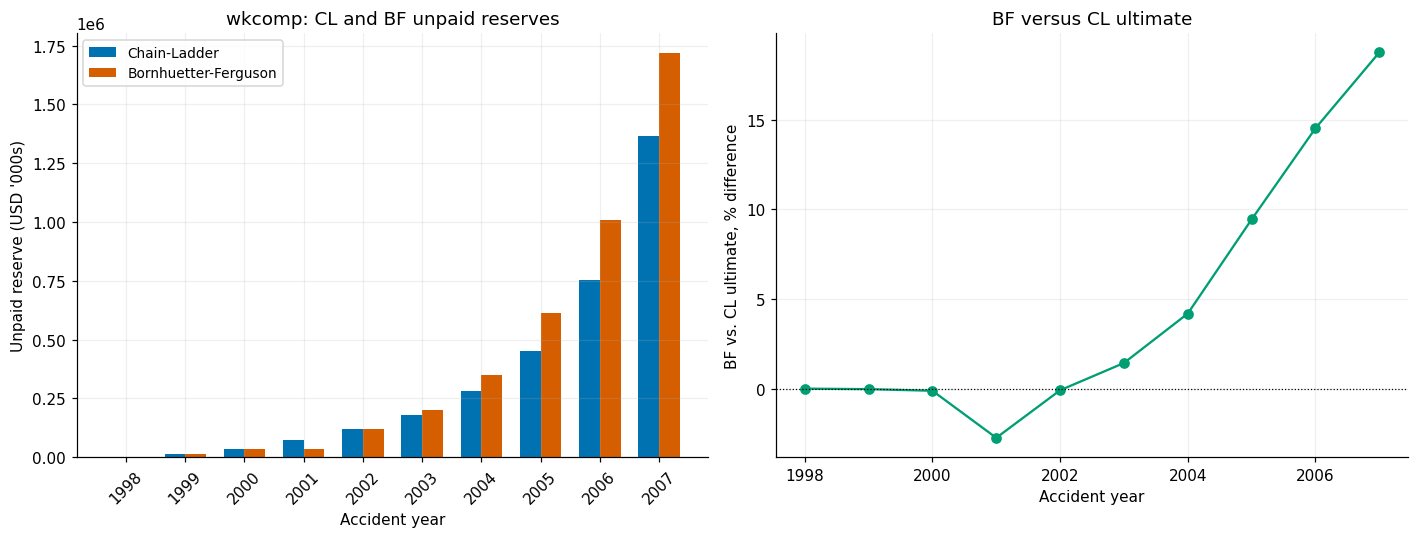

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(compare))
width = 0.35
axes[0].bar(x - width/2, compare['CL_unpaid'], width, label='Chain-Ladder', color='C0')
axes[0].bar(x + width/2, compare['BF_unpaid'], width, label='Bornhuetter-Ferguson', color='C3')
axes[0].set_xticks(x); axes[0].set_xticklabels(compare.index, rotation=45)
axes[0].set_ylabel("Unpaid reserve (USD '000s)"); axes[0].set_xlabel('Accident year')
axes[0].set_title(f'{PRIMARY_LINE}: CL and BF unpaid reserves')
axes[0].legend()

axes[1].plot(compare.index, compare['pct_diff_ultimate'], 'o-', color='C2')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Accident year'); axes[1].set_ylabel('BF vs. CL ultimate, % difference')
axes[1].set_title('BF versus CL ultimate')

plt.tight_layout(); plt.show()

BF is higher than CL, mainly in the recent years (2007: 2,227,803 vs 1,876,207 ultimate). The gap shows how much the answer depends on the prior and development assumptions. It is not an uncertainty interval (that is 09).

## Commercial auto

In [13]:
cum_paid_comauto_full = tri_comauto['cum_paid']
earned_prem_comauto = tri_comauto['earned_prem']
cum_paid_comauto = rsv.mask_to_valuation(cum_paid_comauto_full, VALUATION_YEAR)

val_comauto = rsv.validate_triangle(cum_paid_comauto)
print(val_comauto)
assert val_comauto.n_negative_incremental == 0 and val_comauto.cumulative_matches_sum_of_incremental

cl_comauto = rsv.chain_ladder(cum_paid_comauto)
tail_comauto = rsv.assess_tail_factor(cl_comauto.age_to_age_factors)
elr_comauto = rsv.a_priori_elr_from_mature_years(cl_comauto, earned_prem_comauto)
bf_comauto = rsv.bornhuetter_ferguson(cl_comauto, earned_prem_comauto, elr_comauto)

print(f"\n{SECONDARY_LINE} last age-to-age factor (lag 9->10): {tail_comauto['last_factor']:.4f} "
      f"({tail_comauto['pct_above_unity']:.2f}% above 1.0)")
print(f"{SECONDARY_LINE} a priori ELR: {elr_comauto:.4f}")
print(f"{SECONDARY_LINE} total CL unpaid reserve: {USD000(cl_comauto.unpaid_reserve.sum())}")
print(f"{SECONDARY_LINE} total BF unpaid reserve: {USD000(bf_comauto.unpaid_reserve.sum())}")

TriangleValidationReport(n_accident_years=10, n_negative_incremental=0, n_nonmonotonic_ay=0, cumulative_matches_sum_of_incremental=True)

comauto last age-to-age factor (lag 9->10): 1.0022 (0.22% above 1.0)
comauto a priori ELR: 0.7112
comauto total CL unpaid reserve: USD 2,064,726.9k
comauto total BF unpaid reserve: USD 2,601,432.0k


Same steps and conventions for comauto. Last factor 1.0022, ELR 0.7112, unpaid CL 2,064,726.9k and BF 2,601,432.0k.

## Unpaid claims

Paid ultimate minus paid to date covers both unreported claims and unpaid reported claims. The total can't be split into IBNR and case reserves from paid data alone.

In [14]:
import chainladder as cl_pkg
reserving_results = {}
for line, triangle, estimate, bf_estimate in [('wkcomp', cum_paid, cl, bf), ('comauto', cum_paid_comauto, cl_comauto, bf_comauto)]:
    reference = cl_pkg.Chainladder().fit(cl_pkg.Development(average='volume').fit_transform(rsv.package_triangle(triangle)))
    np.testing.assert_allclose(estimate.age_to_age_factors, reference.ldf_.values.ravel()[:9], rtol=1e-6, atol=1e-6)
    np.testing.assert_allclose(estimate.ultimate, reference.ultimate_.values.ravel(), rtol=1e-6, atol=1e-6)
    reserving_results[line] = dict(CL_unpaid=float(estimate.unpaid_reserve.sum()), BF_unpaid=float(bf_estimate.unpaid_reserve.sum()))
json.dump({'currency':'USD thousands', 'valuation_year':VALUATION_YEAR, 'tail_factor':1.0, 'lines':reserving_results,
           'sample_selection':selection.reset_index().to_dict('records')},
          open(result_path('reserving_results.json'),'w'), indent=2)
print('Both line factor and ultimate comparisons passed: rtol=1e-6, atol=1e-6.')

Both line factor and ultimate comparisons passed: rtol=1e-6, atol=1e-6.


- Future development is masked before estimation.
- CL and BF are run for both lines; wkcomp unpaid 3.27bn (CL) and 4.09bn (BF), comauto 2.06bn and 2.60bn, all USD.
- The triangle covers only full-square companies (see the selection table), not the whole market.
- Package checks use volume weighting, tail 1.0 and rtol = atol = 1e-6.
- No tail beyond lag 10 and no independent BF prior.

In [15]:
record_results('reserving_results.json')